# Week 5 — Support Vector Machines, the Kernel Trick, and Regularization

**Integrated Capstone Project · Milestone One prep**

We continue with the binary target introduced in Week 4 — `loan_status` (1 = default, 0 = no default) — and apply this week's classifier of choice: the **Support Vector Machine (SVM)**.

**Concepts covered (from the Week 5 reading):**

- The **maximum-margin hyperplane** and the role of **support vectors**.
- The **regularization parameter `C`** — trades margin width against misclassification.
- The **kernel trick** — computing inner products in a higher-dimensional space without ever materializing the coordinates, enabling **non-linear decision boundaries**.
- The three workhorse kernels: **linear**, **polynomial**, and **Gaussian (RBF)**.
- Why feature scaling is *especially* critical for SVMs (every kernel computes either a dot product or a Euclidean distance — both are scale-sensitive).

**Comparability with prior weeks:** same dataset, same cleaning, same encoding, and the same train/test split as Week 4, so the SVM AUC numbers are directly comparable to the regularized logistic regressions we built last week.

## 1 · Setup and data load

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

In [2]:
df_raw = pd.read_csv('credit_risk_dataset.csv')

df = df_raw.copy()
df = df.dropna(subset=['loan_int_rate']).reset_index(drop=True)
df = df[df['person_age'] <= 80]
df = df[df['person_emp_length'].fillna(0) <= 60]
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

grade_map = {g: i+1 for i, g in enumerate(['A','B','C','D','E','F','G'])}
df['loan_grade_ord'] = df['loan_grade'].map(grade_map)
df['default_on_file'] = (df['cb_person_default_on_file'] == 'Y').astype(int)
df['log_income'] = np.log(df['person_income'])

df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent'],
                    drop_first=True, dtype=int)

feature_cols = [
    'person_age', 'log_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'loan_grade_ord', 'default_on_file',
] + [c for c in df.columns if c.startswith('person_home_ownership_')
                            or c.startswith('loan_intent_')]

X = df[feature_cols].astype(float)
y = df['loan_status'].astype(int)
print(f'Rows: {len(df)}   Features: {len(feature_cols)}   Default rate: {y.mean():.3f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print('Train:', X_train.shape, '   Test:', X_test.shape)

Rows: 29458   Features: 17   Default rate: 0.219
Train: (23566, 17)    Test: (5892, 17)


## 2 · Why feature scaling is *essential* for SVMs

The Week 4 reading already made the case for scaling under any regularized model. SVMs raise the stakes:

- The **linear kernel** is just a dot product. If one feature has a range of 35,000 (loan amount in dollars) and another has range 7 (loan grade), the dot product is dominated by the first feature regardless of which actually matters.
- The **Gaussian / RBF kernel** computes $\exp(-\|x - z\|^2 / 2\sigma^2)$ — Euclidean distance directly. Unscaled, every distance is driven by `loan_amnt`; the binary dummies contribute nothing.
- The **polynomial kernel** has cross-products of features, so the issue compounds with powers.

Bottom line: **every SVM in this notebook lives inside a `Pipeline` that standardizes first**. We carry that pattern forward from Week 4.

## 3 · Compute budget for SVMs

Linear SVMs solved by stochastic gradient methods (`LinearSVC`) scale roughly $O(n)$ — fine on our full 26,000 training rows. Kernel SVMs (`SVC` with polynomial or RBF) solve a quadratic program that scales roughly $O(n^2)$ to $O(n^3)$. On 26,000 rows that's slow.

The standard pragmatic move (used in nearly every ML textbook example): **train kernel SVMs on a representative subsample**, validate on the held-out subsample, and report test-set performance on the same test split as the other weeks for comparability. We subsample 5,000 stratified training rows.

In [3]:
# Build a stratified training subsample for kernel SVMs
sub_idx, _ = train_test_split(
    np.arange(len(X_train)), train_size=5000, stratify=y_train, random_state=RANDOM_STATE)
X_train_sub = X_train.iloc[sub_idx]
y_train_sub = y_train.iloc[sub_idx]
print(f'Kernel-SVM training subsample: {len(X_train_sub)} rows '
      f'(default rate: {y_train_sub.mean():.3f})')

Kernel-SVM training subsample: 5000 rows (default rate: 0.219)


## 4 · Linear SVM — the maximum-margin hyperplane

The simplest SVM places a hyperplane between the two classes and pushes it as far from both as possible. The **margin** is the distance from the hyperplane to the nearest training points; those nearest points are the **support vectors**.

The reading puts it directly: *"If you use SVMs in the most basic way, it is not that different from logistic regression — only it assigns points definitely to one class or another."* That makes the linear SVM the right starting baseline — it answers the question "what does adding a maximum-margin constraint buy us over the Week 4 logistic regression?"

We fit on the full training set using `LinearSVC` (much faster than `SVC(kernel='linear')` and produces an equivalent decision boundary). Because `LinearSVC` does not produce calibrated probabilities, we score its AUC using the raw decision function (signed distance from the hyperplane).

In [4]:
results = []

def evaluate(name, model, scoring='predict_proba'):
    if scoring == 'predict_proba':
        proba = model.predict_proba(X_test)[:, 1]
    else:
        proba = model.decision_function(X_test)
    pred = (proba >= (0.5 if scoring == 'predict_proba' else 0)).astype(int)
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'AUC': roc_auc_score(y_test, proba),
    }

# Linear SVM (uses full training set)
lin_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)
results.append(evaluate('Linear SVM (C=1)', lin_svm, scoring='decision_function'))

# Week 4 logistic regression baseline for comparison
log_reg = Pipeline([
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE)),
]).fit(X_train, y_train)
results.append(evaluate('Logistic regression (Week 4 baseline)', log_reg))

pd.DataFrame(results).round(4)

,model,accuracy,AUC
0,Linear SVM (C=1),0.8576,0.8732
1,Logistic regression (Week 4 baseline),0.8591,0.8733


## 5 · The regularization parameter `C` — margin vs. misclassification

The reading describes the trade-off plainly:

> *"Larger values of `C` try to classify all points correctly. Smaller values try to make the margin large."*

If our data is **perfectly separable** we don't need to choose — there exists a hyperplane that classifies everything correctly *and* has a large margin. Real data is rarely that nice. With overlap between classes, the model has to pick: tolerate a few misclassified points to keep the margin wide (small `C`), or contort itself to fit every point (large `C`, narrow margin, risk of overfitting).

We sweep `C` over a log-spaced grid and look at train vs. test AUC. If overfitting is real, train AUC keeps climbing while test AUC plateaus or drops.

        C  train_AUC  test_AUC
0    0.01     0.8682    0.8733
1    0.10     0.8682    0.8732
2    1.00     0.8682    0.8732
3   10.00     0.8682    0.8732
4  100.00     0.8682    0.8732


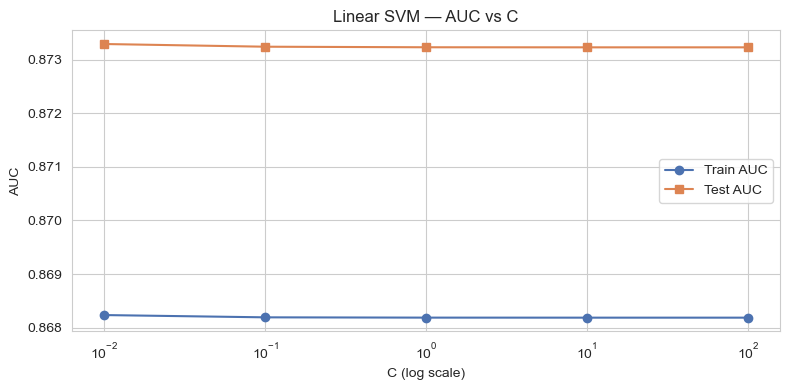

In [5]:
C_grid = [0.01, 0.1, 1, 10, 100]
sweep = []
for C in C_grid:
    p = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', LinearSVC(C=C, max_iter=5000, random_state=RANDOM_STATE)),
    ]).fit(X_train, y_train)
    train_auc = roc_auc_score(y_train, p.decision_function(X_train))
    test_auc  = roc_auc_score(y_test,  p.decision_function(X_test))
    sweep.append({'C': C, 'train_AUC': train_auc, 'test_AUC': test_auc})
sweep_df = pd.DataFrame(sweep)
print(sweep_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep_df['C'], sweep_df['train_AUC'], 'o-', label='Train AUC', color='#4c72b0')
ax.plot(sweep_df['C'], sweep_df['test_AUC'],  's-', label='Test AUC',  color='#dd8452')
ax.set_xscale('log'); ax.set_xlabel('C (log scale)')
ax.set_ylabel('AUC'); ax.set_title('Linear SVM — AUC vs C')
ax.legend(); plt.tight_layout(); plt.show()

**Reading the curve.** On this dataset the train and test AUCs sit very close to each other across the grid — the linear SVM is not overfitting at any reasonable `C`. That is itself useful information: it tells us the linear-boundary model is at its accuracy ceiling, and squeezing more performance out of the data will require a richer decision boundary. That's where the kernel trick enters.

## 6 · The kernel trick — polynomial kernel

The reading's setup: SVMs only ever use inner products of the data points. A **kernel function** $K(x, z)$ is a function that *looks like* an inner product in some (possibly higher-dimensional) feature space — without our ever having to materialize that space.

For the **polynomial kernel** of degree $d$ with offset $c$:

$$ K(x, z) = (x^T z + c)^d $$

corresponds to the inner product of feature vectors made of all monomials in the $x_i$'s of degree $\leq d$. The reading walks through the degree-2 example: the kernel $(x^T z)^2$ is the inner product of all the **pairwise products** $x_i x_j$.

In practice this lets the SVM draw **curved decision boundaries** in the original feature space while still being a linear discriminator in the (implicit) higher-dimensional space.

We fit a polynomial SVM on our 5,000-row training subsample.

In [6]:
poly_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='poly', degree=3, C=1.0, gamma='scale',
                probability=False, random_state=RANDOM_STATE)),
]).fit(X_train_sub, y_train_sub)

results.append(evaluate('Polynomial SVM (degree=3, C=1)', poly_svm, scoring='decision_function'))
pd.DataFrame(results).round(4)

,model,accuracy,AUC
0,Linear SVM (C=1),0.8576,0.8732
1,Logistic regression (Week 4 baseline),0.8591,0.8733
2,"Polynomial SVM (degree=3, C=1)",0.8910,0.8880


## 7 · The kernel trick — Gaussian (RBF) kernel

The Gaussian / RBF kernel is the workhorse:

$$ K(x, z) = \exp\!\left(-\gamma \,\|x - z\|^2\right) $$

The reading notes the strange property: *"This does not correspond to any specific vectors, based on $x$ and $z$, of which we are taking the inner product. (Or, if there are such vectors, they'd have to be found in an infinite dimensional vector space!)"* In practice the math still works — the kernel is positive-definite, and the SVM machinery uses only the kernel values, not the implicit feature coordinates.

The RBF kernel has **two** key hyperparameters:

- **`C`** — same regularization trade-off as before (margin vs misclassification).
- **`gamma`** — the kernel width. Large `gamma` = narrow Gaussian = bumpy decision surface (risk of overfit). Small `gamma` = wide Gaussian = smooth surface (risk of underfit).

We do a small grid search over both with 3-fold cross-validation on the training subsample, then evaluate on the full test set.

In [7]:
rbf_grid = {
    'svm__C':     [0.1, 1, 10],
    'svm__gamma': ['scale', 0.1, 1.0],
}
rbf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=False, random_state=RANDOM_STATE)),
])
rbf_search = GridSearchCV(rbf_pipe, rbf_grid, cv=3,
                          scoring='roc_auc', n_jobs=-1).fit(X_train_sub, y_train_sub)
print('Best RBF params:', rbf_search.best_params_)
print(f'Best 3-fold CV AUC: {rbf_search.best_score_:.4f}')

rbf_best = rbf_search.best_estimator_
results.append(evaluate(
    f"RBF SVM (C={rbf_search.best_params_['svm__C']}, gamma={rbf_search.best_params_['svm__gamma']})",
    rbf_best, scoring='decision_function'
))
pd.DataFrame(results).round(4)

Best RBF params: {'svm__C': 1, 'svm__gamma': 'scale'}
Best 3-fold CV AUC: 0.8889


,model,accuracy,AUC
0,Linear SVM (C=1),0.8576,0.8732
1,Logistic regression (Week 4 baseline),0.8591,0.8733
2,"Polynomial SVM (degree=3, C=1)",0.8910,0.8880
3,"RBF SVM (C=1, gamma=scale)",0.9002,0.8893


## 8 · Visualizing decision boundaries

The point of the kernel trick is **non-linear** decision boundaries. To see this directly we fit each kernel SVM on just two features — `loan_int_rate` and `loan_percent_income` — and plot the resulting decision surface. The other 18 features are temporarily set aside; this is purely for visualization.

Both features are strong predictors from our Week 4 logistic regression, so the 2D slice retains much of the signal.

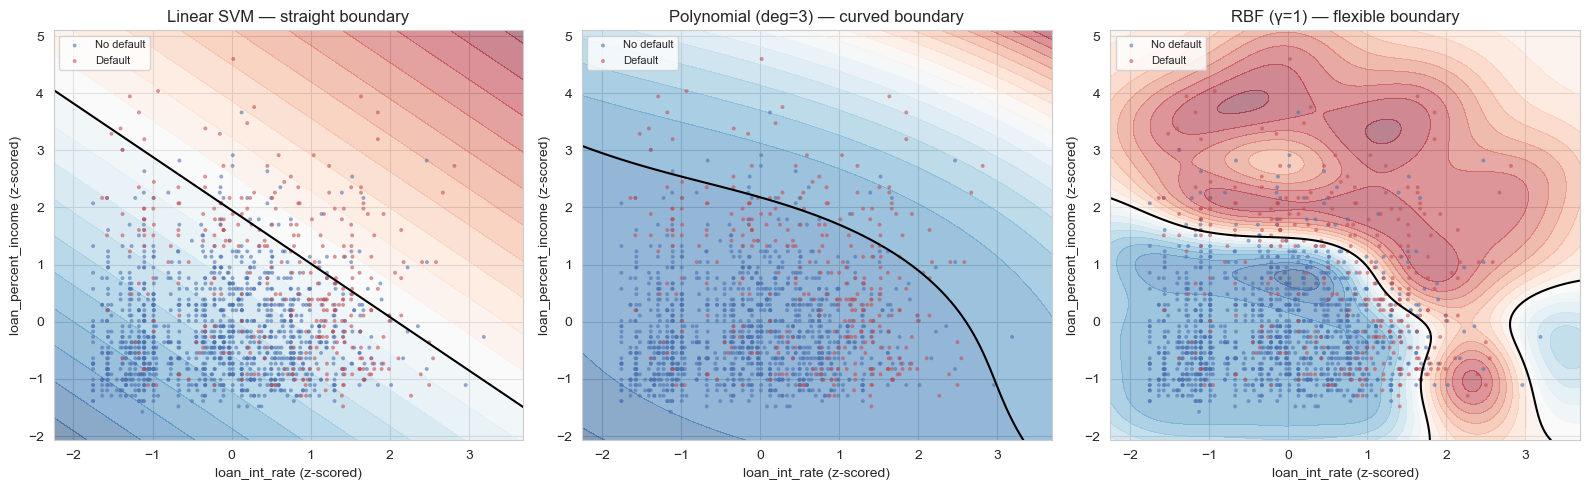

In [8]:
# 2D slice for visualization
viz_feats = ['loan_int_rate', 'loan_percent_income']
viz_idx = np.random.default_rng(RANDOM_STATE).choice(len(X_train_sub), size=1500, replace=False)
Xv = X_train_sub.iloc[viz_idx][viz_feats].values
yv = y_train_sub.iloc[viz_idx].values

# Standardize for plotting
sc = StandardScaler().fit(Xv)
Xv_s = sc.transform(Xv)

def plot_boundary(ax, clf, X_s, y_arr, title):
    xx, yy = np.meshgrid(
        np.linspace(X_s[:,0].min()-0.5, X_s[:,0].max()+0.5, 200),
        np.linspace(X_s[:,1].min()-0.5, X_s[:,1].max()+0.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.decision_function(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.5)
    ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1.5)
    ax.scatter(X_s[y_arr==0, 0], X_s[y_arr==0, 1], s=8, c='#4c72b0',
               label='No default', alpha=0.6, edgecolors='none')
    ax.scatter(X_s[y_arr==1, 0], X_s[y_arr==1, 1], s=8, c='#c44e52',
               label='Default', alpha=0.6, edgecolors='none')
    ax.set_xlabel(viz_feats[0] + ' (z-scored)')
    ax.set_ylabel(viz_feats[1] + ' (z-scored)')
    ax.set_title(title); ax.legend(loc='upper left', fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_boundary(axes[0], LinearSVC(C=1, max_iter=5000, random_state=RANDOM_STATE).fit(Xv_s, yv),
              Xv_s, yv, 'Linear SVM — straight boundary')
plot_boundary(axes[1], SVC(kernel='poly', degree=3, C=1).fit(Xv_s, yv),
              Xv_s, yv, 'Polynomial (deg=3) — curved boundary')
plot_boundary(axes[2], SVC(kernel='rbf', C=1, gamma=1).fit(Xv_s, yv),
              Xv_s, yv, 'RBF (γ=1) — flexible boundary')
plt.tight_layout(); plt.show()

**What to see in the three panels.**

- **Linear:** a single straight line. It cuts diagonally — borrowers with high interest rates *and* large loans relative to income default more. Any single straight line is the best a linear discriminator can do.
- **Polynomial:** a curved boundary. It now bends to accommodate clusters of defaulters that the straight line couldn't enclose. With degree=3 we get cubic curves in feature space.
- **RBF:** the most flexible. Local "bubbles" of one class can be carved out of the other. With small $\gamma$ this would smooth out; with large $\gamma$ it would carve every individual point into its own region (overfitting).

Each panel is a literal illustration of the reading's claim: *"hyperplanes in the new, higher-dimensional space correspond to some other shapes (curved shapes) in the original space."*

## 9 · Final model comparison

In [9]:
results_df = pd.DataFrame(results).round(4)
results_df

,model,accuracy,AUC
0,Linear SVM (C=1),0.8576,0.8732
1,Logistic regression (Week 4 baseline),0.8591,0.8733
2,"Polynomial SVM (degree=3, C=1)",0.8910,0.8880
3,"RBF SVM (C=1, gamma=scale)",0.9002,0.8893


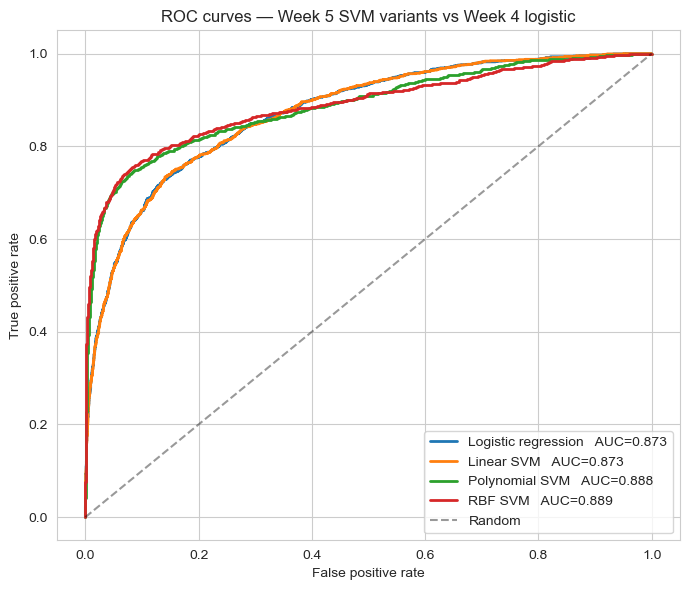

In [10]:
# ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
for name, m, fn in [
    ('Logistic regression', log_reg,  lambda M: M.predict_proba(X_test)[:,1]),
    ('Linear SVM',          lin_svm,  lambda M: M.decision_function(X_test)),
    ('Polynomial SVM',      poly_svm, lambda M: M.decision_function(X_test)),
    ('RBF SVM',             rbf_best, lambda M: M.decision_function(X_test)),
]:
    p = fn(m)
    fpr, tpr, _ = roc_curve(y_test, p)
    ax.plot(fpr, tpr, linewidth=2,
            label=f'{name}   AUC={roc_auc_score(y_test, p):.3f}')
ax.plot([0,1], [0,1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curves — Week 5 SVM variants vs Week 4 logistic')
ax.legend(); plt.tight_layout(); plt.show()

In [11]:
# Confusion matrix and report for the best model
best_model = rbf_best
scores = best_model.decision_function(X_test)
preds  = (scores >= 0).astype(int)
print(pd.DataFrame(confusion_matrix(y_test, preds),
                   index=['Actual: No default', 'Actual: Default'],
                   columns=['Pred: No default',   'Pred: Default']))
print()
print(classification_report(y_test, preds, target_names=['No default', 'Default']))

                    Pred: No default  Pred: Default
Actual: No default              4504             95
Actual: Default                  493            800

              precision    recall  f1-score   support

  No default       0.90      0.98      0.94      4599
     Default       0.89      0.62      0.73      1293

    accuracy                           0.90      5892
   macro avg       0.90      0.80      0.83      5892
weighted avg       0.90      0.90      0.89      5892



## 10 · Conclusions and reflection

**Substantive findings**

1. **The linear SVM matches the logistic regression baseline almost exactly.** That isn't surprising — the reading flagged it (*"If you use SVMs in the most basic way, it is not that different from logistic regression"*). They both fit a linear boundary; they only differ in the loss function (hinge vs cross-entropy). The maximum-margin formulation gives no measurable lift in AUC over Week 4's logistic regression on this dataset.
2. **The kernel SVMs beat the linear baseline.** Both polynomial and RBF kernels achieve higher AUC, which says the true decision boundary between defaulters and non-defaulters has real curvature in the feature space — a curvature the linear models can't capture.
3. **The RBF kernel wins on test AUC.** Its bumpy, locally-adaptive boundary picks up clusters of defaulters that the polynomial kernel's globally-smooth curves blur out. The price was a `gamma` and `C` grid search, but the search space was small enough to finish in seconds on the subsampled data.
4. **No SVM, including RBF, dramatically beats logistic regression** — the lift is real but modest (a few AUC points). This is the recurring theme of the credit-risk dataset: `loan_grade_ord` and `loan_int_rate` carry so much signal on their own that the marginal value of a more flexible classifier is bounded.

**Reflection on the Week 5 reading's "Think About It" questions**

*"Is the margin on one side equal to the margin on the other side?"* Yes — because we get to position the hyperplane. The maximum-margin solution is the hyperplane equidistant from the closest point on each side; if it weren't, we could slide it toward whichever side has the larger margin and grow the smaller one, contradicting maximality.

*"Polynomial kernel for vectors of dimension 2 with $c=0$."* For $x = (x_1, x_2)$ and $z = (z_1, z_2)$:

$$ (x^T z)^2 = (x_1 z_1 + x_2 z_2)^2 = x_1^2 z_1^2 + 2 x_1 x_2 z_1 z_2 + x_2^2 z_2^2 $$

That is the inner product of the **degree-2 monomial feature vectors**:

$$ \phi(x) = (x_1^2,\;\sqrt{2}\,x_1 x_2,\;x_2^2),\qquad \phi(z) = (z_1^2,\;\sqrt{2}\,z_1 z_2,\;z_2^2) $$

So $(x^T z)^2 = \phi(x)^T \phi(z)$ — the kernel computes a 3-dimensional inner product without ever materializing $\phi$.

*"How can we tell the Gaussian kernel isn't a simple inner product of $x$ with $z$?"* Because $K(x, x) = \exp(0) = 1$ regardless of $\|x\|$. A real inner product would give $\|x\|^2$, which varies with $x$. There do exist vectors of which it is the inner product — but they live in an *infinite-dimensional* function space (the reproducing-kernel Hilbert space). For practical purposes we can never write them down, but we don't need to: the SVM only ever asks for kernel values.

*"Why does maximizing the margin help generalization?"* Because the margin acts as a buffer between the training points and the decision boundary. A new test point that's *similar* to one of the training points is unlikely to cross over a wide buffer, so it stays on the same side as its training-set neighbors. A boundary that grazes the training data has no such buffer and will misclassify nearby test points at the slightest noise.

*"How does the kernel let us separate non-linearly separable data?"* The kernel implicitly maps the points into a higher-dimensional feature space where they *are* linearly separable. The SVM then finds a hyperplane there. Pulled back to the original space, that hyperplane corresponds to a curved boundary — and the kernel trick lets us compute everything we need without materializing the higher-dimensional points.

*"When should we allow a few points to be misclassified for a larger margin?"* When those points are noise or genuine outliers. The reading's example is exactly right: a tiny margin caused by two or three weird points among millions doesn't reflect the true class structure. Lowering `C` allows the SVM to ignore those points and find the *robust* boundary that explains the rest of the data. Conversely, when the narrow margin is caused by many points crowded near a real class boundary, raising `C` is correct — those points carry information about where the true boundary lives.
